# Noise-floor jitter bands for dead features

A **dead** (pure-noise) feature's weight and Autostep gradient trace are stationary, with a jitter
amplitude set entirely by the learned step-size, the residual power, and the L1 coefficient:

$$s_i = \sqrt{\frac{\alpha_i \, \mathbb{E}[\delta^2]}{2}}, \qquad
  |w_i| \le s_i - \frac{\lambda}{\mathbb{E}[x_i^2]}, \qquad
  |h_i| \le \frac{s_i}{\sqrt{2}}$$

Each band is a **one-sigma** band, so if it is right the quantity's rms equals the band exactly and
it sits inside the band $2\Phi(1) - 1 = 68.3\%$ of the time. The algorithm has to build the bands
online, estimating $\mathbb{E}[\delta^2]$ with the `v` trace and $\mathbb{E}[x_i^2]$ with a second
trace on the same horizon; every table below therefore compares that **learned** band against the
**analytic** band built from the measured $\mathbb{E}[\delta^2]$ and the true $\mathbb{E}[x_i^2]$.

Three learners are measured in turn: **LMS**, **LMS + L1**, and **LMS + L1 + Autostep** -- with the
L1 learner also judged against the no-L1 bands, to see how much the $\lambda$ term matters. L1 enters
through the gradient ($\lambda \, \mathrm{sign}(w)$ added to $\delta x$) so that Autostep's step-size
adaptation sees it too.

**Setup.** One seed, one `FeatureSiftingTask` supplying the target $y$, and a bank of `N_FEATURES`
*independent single-input learners*: learner $i$ owns one pure-noise feature $x_i \sim
\mathcal{N}(\mu_i, \sigma_i^2)$ (a different distribution per feature) and predicts $y$ from it
alone, so $\delta_i = w_i x_i - y$. Every feature is a dead feature by construction, and 10k of them
give the statistics cheaply. Pruning is deliberately **disabled** — the point is to measure the
un-pruned jitter the bands are meant to describe.

In [85]:
import numpy as np
import pandas as pd
import jax
import jax.numpy as jnp
import equinox as eqx
import optax

import matplotlib.pyplot as plt
from scipy.stats import norm

from phd.jax_core.tasks.feature_sifting import FeatureSiftingTask
from phd.jax_core.optimizers.idbd import optax_idbd
from phd.jax_core.utils import tree_replace

In [86]:
# Task configuration (the task only supplies the target y here).
N_TARGET_FEATURES = 10
N_LEARNER_FEATURES = 20
TARGET_NOISE_STD = 1.0
NO_PRUNE = jnp.zeros(N_LEARNER_FEATURES, dtype=bool)

# Probe configuration.
N_FEATURES = 10_000     # independent single-feature learners, each on a pure-noise feature
N_BURN_IN = 40_000      # steps discarded so w, h and the traces reach their stationary distributions
N_SNAPSHOTS = 250       # snapshots kept for the statistics
RECORD_EVERY = 4_000    # steps between snapshots -- all features share one y sequence, so
                        # snapshots must be spread out to average over its slow common drift
BASE_SEED = 0

# Algorithm hyperparameters.
LEARNING_RATE = 2.0 ** -8
META_LEARNING_RATE = 2.0 ** -6
L1_COEFF = 0.01        # large enough to move the w band, small enough to keep it positive
K_V = 5.0               # both traces average over ~K_V of the learner's own adaptation timescales

PCT_OUTSIDE_1SIGMA = 100.0 * 2.0 * norm.sf(1.0)   # 31.7%: what a correct one-sigma band leaves out

## Features, bands and learner

Each feature gets its own mean and standard deviation, so the bank spans a wide range of
$\mathbb{E}[x_i^2]$ — which the $s_i$ term says should cancel out of the band, and the L1 term says
should not.

In [87]:
def sample_feature_dists(key):
    """Per-feature noise distributions: mean ~ U[-1, 1], std ~ log-uniform[0.1, 3]."""
    mu_key, sigma_key = jax.random.split(key)
    mu = jax.random.uniform(mu_key, (N_FEATURES, 1), minval=-1.0, maxval=1.0)
    log_sigma = jax.random.uniform(sigma_key, (N_FEATURES, 1),
                                   minval=jnp.log(0.1), maxval=jnp.log(3.0))
    return mu, jnp.exp(log_sigma)


def jitter_bands(step_size, delta2, x2, l1_coeff):
    """One-sigma jitter bands for a dead feature, from estimates of E[delta^2] and E[x^2].
    Called with the learner's traces online, and with the measured truth for comparison."""
    s = (step_size * delta2 / 2.0) ** 0.5
    return s - l1_coeff / x2, s / 2.0 ** 0.5      # (w band, h band)

In [88]:
class NoiseFloorProbe(eqx.Module):
    """A bank of `N_FEATURES` independent single-input linear learners sharing one target.

    Weights are shaped `(N_FEATURES, 1)`, so every per-feature quantity the optimizer computes --
    including Autostep's effective-step-size normaliser, which reduces over the last axis -- is
    computed per learner. `autostep=False` gives plain LMS (a fixed step-size, `meta_lr=0`) while
    still maintaining the IDBD gradient trace `h`, so the same bands can be evaluated."""
    optimizer: optax.GradientTransformation = eqx.field(static=True)
    l1_coeff: float = eqx.field(static=True)
    w: jax.Array          # (N_FEATURES, 1)
    opt_state: optax.OptState
    v: jax.Array          # (N_FEATURES, 1) trace of delta^2
    x2: jax.Array         # (N_FEATURES, 1) trace of x^2, same horizon as v

    @classmethod
    def init(cls, l1_coeff=0.0, autostep=False):
        optimizer = optax_idbd(init_lr=LEARNING_RATE,
                               meta_lr=META_LEARNING_RATE if autostep else 0.0,
                               autostep=autostep)
        w = jnp.zeros((N_FEATURES, 1))
        return cls(optimizer=optimizer, l1_coeff=l1_coeff, w=w, opt_state=optimizer.init(w),
                   v=jnp.zeros((N_FEATURES, 1)), x2=jnp.zeros((N_FEATURES, 1)))

    def step(self, x, y):
        error = self.w * x - y                            # delta_i, one residual per learner
        loss = error ** 2
        loss_grads = error * x + self.l1_coeff * jnp.sign(self.w)   # L1 inside the gradient

        updates, opt_state = self.optimizer.update((loss_grads, x), self.opt_state, self.w)
        w = optax.apply_updates(self.w, updates)

        step_size = jnp.exp(opt_state.beta)
        gain = step_size * x ** 2 / K_V                   # shared horizon for both traces
        v = self.v + gain * (loss - self.v)
        x2 = self.x2 + gain * (x ** 2 - self.x2)

        snapshot = dict(w=w, h=opt_state.h, v=v, x2=x2, loss=loss, step_size=step_size)
        return tree_replace(self, w=w, opt_state=opt_state, v=v, x2=x2), snapshot

In [89]:
def run(l1_coeff=0.0, autostep=False, seed=BASE_SEED):
    """Burn in, then take `N_SNAPSHOTS` snapshots `RECORD_EVERY` steps apart. Returns flat numpy
    arrays of every recorded per-feature quantity, plus the analytic bands built from the truth."""
    task_key, feature_key, noise_key = jax.random.split(jax.random.PRNGKey(seed), 3)
    task = FeatureSiftingTask(N_TARGET_FEATURES, N_LEARNER_FEATURES, TARGET_NOISE_STD, key=task_key)
    mu, sigma = sample_feature_dists(feature_key)
    state = NoiseFloorProbe.init(l1_coeff, autostep)

    def learn_step(carry, _):
        task, state, key = carry
        key, x_key = jax.random.split(key)
        task, (_, y) = task.step(NO_PRUNE)     # only the target is used; the task's own features are not
        x = mu + sigma * jax.random.normal(x_key, (N_FEATURES, 1))
        state, snapshot = state.step(x, y)
        return (task, state, key), snapshot

    def advance(carry, n_steps):               # run `n_steps` without keeping the snapshots
        carry, _ = jax.lax.scan(lambda c, _: (learn_step(c, None)[0], None), carry, length=n_steps)
        return carry

    @eqx.filter_jit
    def go():
        carry = advance((task, state, noise_key), N_BURN_IN)
        _, snapshots = jax.lax.scan(lambda c, _: learn_step(advance(c, RECORD_EVERY - 1), None),
                                    carry, length=N_SNAPSHOTS)
        return snapshots

    rec = jax.tree.map(lambda a: np.asarray(a).ravel(), go())
    rec['x2_true'] = np.tile(np.asarray(mu ** 2 + sigma ** 2).ravel(), N_SNAPSHOTS)
    return with_bands(rec, l1_coeff)


def with_bands(rec, l1_coeff):
    """Attach the bands for a given lambda to an existing run -- everything they need was recorded.
    Lets an L1 learner be re-judged against the bands of a different (e.g. zero) coefficient."""
    rec = dict(rec)
    rec['band_w'], rec['band_h'] = jitter_bands(rec['step_size'], rec['v'], rec['x2'], l1_coeff)
    rec['band_w_true'], rec['band_h_true'] = jitter_bands(
        rec['step_size'], rec['loss'].mean(), rec['x2_true'], l1_coeff)
    return rec

## Statistics

Two things are being checked for each of $w$ and $h$:

- **is the band right?** `% outside analytic band` should equal the 31.7% a correct one-sigma band
  leaves out.
- **does the learner recover it?** `% outside learned band` should match too, and
  `learned / analytic band` should be 1 — it drifts when the `v` or $x^2$ trace is a biased estimate
  of what it stands in for. The ratio is reported as a median because a band close to zero makes the
  mean explode.

A large enough $\lambda$ drives $s_i - \lambda / \mathbb{E}[x_i^2]$ negative for the weakest
features: L1 alone pins those weights at zero, so they have no band to test and are excluded.

In [90]:
def summarize(rec):
    ok = rec['band_w_true'] > 0        # L1 alone pins these at zero -- no band to test
    delta2 = rec['loss'].mean()
    out = {'E[delta^2]': delta2,
           'mean(v) / E[delta^2]': (rec['v'] / delta2).mean(),
           'mean(x2 trace) / E[x^2]': (rec['x2'] / rec['x2_true']).mean(),
           '% excluded (band <= 0)': 100.0 * (~ok).mean(),
           'target % outside band': PCT_OUTSIDE_1SIGMA}
    for name in ('w', 'h'):
        arr, band, band_true = rec[name][ok], rec[f'band_{name}'][ok], rec[f'band_{name}_true'][ok]
        out[f'{name}: % outside learned band'] = 100.0 * (np.abs(arr) > band).mean()
        out[f'{name}: % outside analytic band'] = 100.0 * (np.abs(arr) > band_true).mean()
        out[f'{name}: learned / analytic band'] = np.median(band / band_true)
    return {k: float(val) for k, val in out.items()}


def table(runs):
    return pd.DataFrame({label: summarize(rec) for label, rec in runs.items()}).round(3)

In [91]:
def plot_distributions(rec, label):
    """Distributions of the v trace and of h, then w and h each divided by its own band. If the
    bands really are one sigma, both rescaled distributions must be standard normal."""
    ok = rec['band_w_true'] > 0
    delta2 = rec['loss'].mean()

    fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))

    axes[0].hist(rec['v'], bins=200, color='C0')
    axes[0].axvline(delta2, color='k', ls='--', label=f'E[$\\delta^2$] = {delta2:.2f}')
    axes[0].set(xlabel='v', ylabel='count', title='v (residual-power trace)')
    axes[0].legend()

    axes[1].hist(rec['h'], bins=200, range=np.quantile(rec['h'], [0.001, 0.999]), color='C1')
    axes[1].set(xlabel='h', title='h (gradient trace)')

    bins = np.linspace(-3, 3, 200)
    axes[2].hist(rec['w'][ok] / rec['band_w'][ok], bins=bins, histtype='step', density=True,
                 color='C2', label='$w_i$ / its band')
    axes[2].hist(rec['h'][ok] / rec['band_h'][ok], bins=bins, histtype='step', density=True,
                 color='C1', label='$h_i$ / its band')
    axes[2].plot(bins, norm.pdf(bins), 'k:', label='$\\mathcal{N}(0, 1)$: band = 1$\\sigma$')
    for edge in (-1, 1):
        axes[2].axvline(edge, color='k', ls='--', lw=1)
    axes[2].set(xlabel='multiples of the band (dashed = the band itself)',
                title='each quantity divided by its own band')
    axes[2].legend(loc='upper left', fontsize=8)

    fig.suptitle(label)
    fig.tight_layout()
    plt.show()

## 1. LMS

No regularisation, so the w band is just $s_i$ and neither band depends on $\mathbb{E}[x_i^2]$.

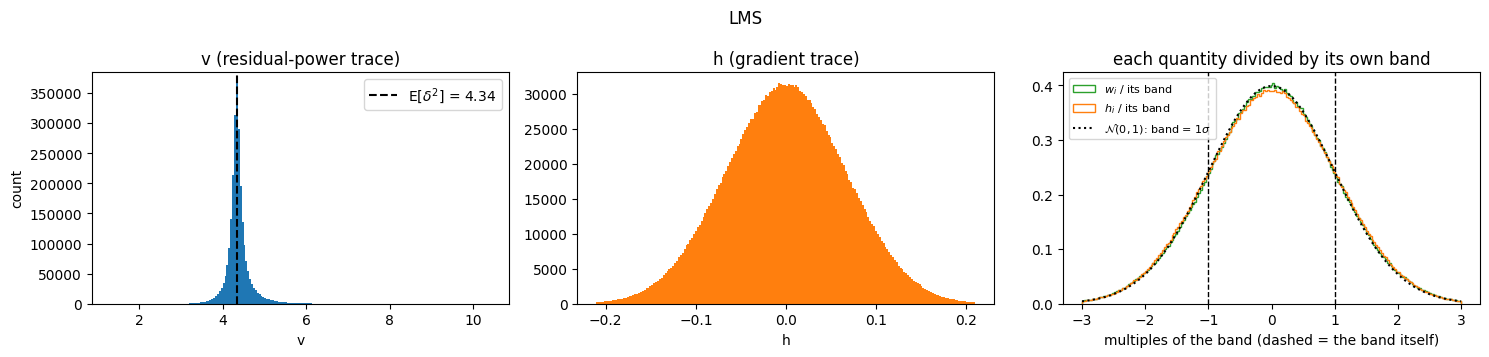

,LMS
E[delta^2],4.344
mean(v) / E[delta^2],1.005
mean(x2 trace) / E[x^2],2.388
% excluded (band <= 0),0.000
target % outside band,31.731
w: % outside learned band,32.331
w: % outside analytic band,32.398
w: learned / analytic band,0.999
h: % outside learned band,33.103
h: % outside analytic band,33.169


In [92]:
lms = run()
plot_distributions(lms, 'LMS')
table({'LMS': lms})

## 2. LMS + L1, judged by the no-L1 bands

$\lambda \, \mathrm{sign}(w)$ joins the gradient, but the bands are left as they were in section 1
($\text{band}_w = s_i$) — how wrong is it to ignore L1 when bounding the jitter? This is the same
run as section 3, only re-judged, and $\text{band}_h$ does not depend on $\lambda$ at all, so the
h rows differ from section 3 only through which samples are excluded.

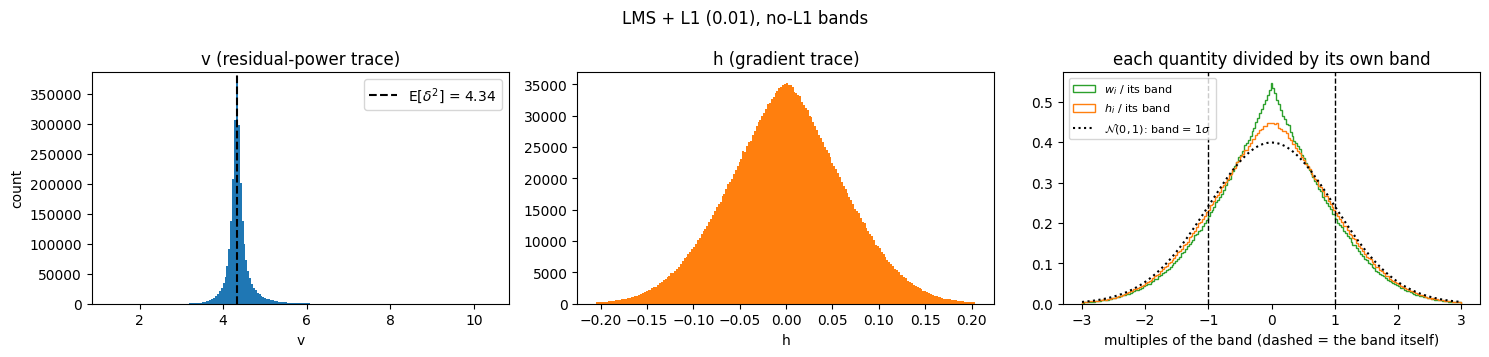

,"LMS + L1, no-L1 bands"
E[delta^2],4.343
mean(v) / E[delta^2],1.004
mean(x2 trace) / E[x^2],2.388
% excluded (band <= 0),0.000
target % outside band,31.731
w: % outside learned band,26.624
w: % outside analytic band,26.715
w: learned / analytic band,0.999
h: % outside learned band,29.491
h: % outside analytic band,29.576


In [93]:
lms_l1 = run(l1_coeff=L1_COEFF)
lms_l1_no_l1_bands = with_bands(lms_l1, 0.0)
plot_distributions(lms_l1_no_l1_bands, f'LMS + L1 ({L1_COEFF}), no-L1 bands')
table({'LMS + L1, no-L1 bands': lms_l1_no_l1_bands})

## 3. LMS + L1

The w band now shrinks by $\lambda / \mathbb{E}[x_i^2]$ — the one place a feature's own input scale
enters.

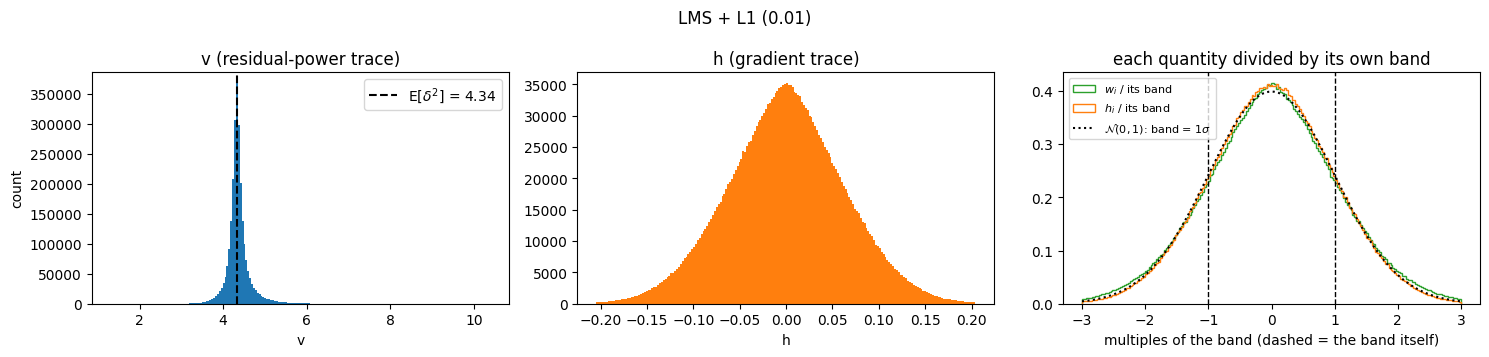

,LMS + L1
E[delta^2],4.343
mean(v) / E[delta^2],1.004
mean(x2 trace) / E[x^2],2.388
% excluded (band <= 0),8.460
target % outside band,31.731
w: % outside learned band,33.355
w: % outside analytic band,39.438
w: learned / analytic band,1.069
h: % outside learned band,31.142
h: % outside analytic band,31.247


In [94]:
plot_distributions(lms_l1, f'LMS + L1 ({L1_COEFF})')
table({'LMS + L1': lms_l1})

## 4. LMS + L1 + Autostep

Same equations, but each feature now learns its own $\alpha_i$, so $s_i$ moves with it.

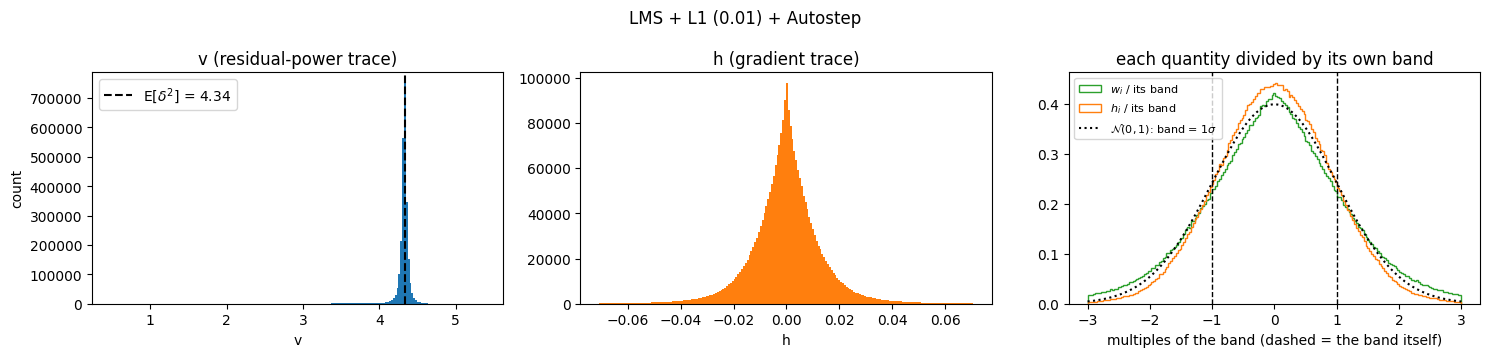

,LMS + L1 + Autostep
E[delta^2],4.337
mean(v) / E[delta^2],0.991
mean(x2 trace) / E[x^2],2.368
% excluded (band <= 0),35.036
target % outside band,31.731
w: % outside learned band,36.239
w: % outside analytic band,51.941
w: learned / analytic band,1.306
h: % outside learned band,27.513
h: % outside analytic band,27.495


In [95]:
autostep_l1 = run(l1_coeff=L1_COEFF, autostep=True)
plot_distributions(autostep_l1, f'LMS + L1 ({L1_COEFF}) + Autostep')
table({'LMS + L1 + Autostep': autostep_l1})

## Comparison

In [96]:
table({'LMS': lms, 'LMS + L1, no-L1 bands': lms_l1_no_l1_bands,
       'LMS + L1': lms_l1, 'LMS + L1 + Autostep': autostep_l1})

,LMS,"LMS + L1, no-L1 bands",LMS + L1,LMS + L1 + Autostep
E[delta^2],4.344,4.343,4.343,4.337
mean(v) / E[delta^2],1.005,1.004,1.004,0.991
mean(x2 trace) / E[x^2],2.388,2.388,2.388,2.368
% excluded (band <= 0),0.000,0.000,8.460,35.036
target % outside band,31.731,31.731,31.731,31.731
w: % outside learned band,32.331,26.624,33.355,36.239
w: % outside analytic band,32.398,26.715,39.438,51.941
w: learned / analytic band,0.999,0.999,1.069,1.306
h: % outside learned band,33.103,29.491,31.142,27.513
h: % outside analytic band,33.169,29.576,31.247,27.495
